# 6×6 farmer↔hunter convert_prob 精细网格（广覆盖参照）

跟进 `hypothesis_validation.ipynb` 的 H3·续（3³ 网格发现 `Farmer.convert_prob.to_hunter` 是主导调节器，~27× 效应），本节把这两条路径的概率细分到 0.02 间隔，原始目的是看是否存在质变阈值。

**该 notebook 在 2026-06 后的定位**：作为 **广覆盖参照** —— f2h 范围延伸到 0.10（5× 于 `2d_fine_v1` 的 0.02），用来说明「为什么 zoom 进 [0, 0.02]」。精细分析在 `convert_prob_2d_fine_v1.ipynb`，本本只展示宏观图景。

**实验设计：**

- `Farmer.convert_prob.to_hunter (f2h) ∈ {0.0, 0.02, 0.04, 0.06, 0.08, 0.1}`
- `Hunter.convert_prob.to_farmer (h2f) ∈ {0.0, 0.02, 0.04, 0.06, 0.08, 0.1}`
- 6×6 = 36 组合 × 5 repeats，每 run 500 步
- 数据：`out/south_china_evolution/grid_f2h_h2f_v1/`

**数据状态**：25/36 组合（缺 11，含 f2h=0 行 3 个、f2h ∈ {0.02, 0.04, 0.06} 区 8 个）。空缺不影响本 notebook 的目的（图 1 用 h2f=0.10 这条完整切片就能讲清悬崖），且 f2h=0 行 3 缺口已被 `2d_fine_v1` 覆盖。不再补跑。


In [1]:
from __future__ import annotations

import itertools
import re
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

PROJECT_ROOT = Path("..").resolve()
GRID_ROOT = PROJECT_ROOT / "out/south_china_evolution/grid_f2h_h2f_v1"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

# 字体配置必须放在 sns.set_theme 之后（否则 set_theme 会重置 rcParams 把字体清掉）。
# 先尝试项目自带 matplotkit (SunTimes)，再补一层 macOS 自带 CJK fallback 防止中文方块。
try:
    from matplotkit import config_font

    config_font("SunTimes")
except Exception:
    pass

import matplotlib as _mpl

_CJK_FONTS = ["PingFang HK", "Hiragino Sans GB", "Songti SC", "STHeiti", "Heiti TC"]
_mpl.rcParams["font.sans-serif"] = _CJK_FONTS + list(_mpl.rcParams["font.sans-serif"])
_mpl.rcParams["font.serif"] = _CJK_FONTS + list(_mpl.rcParams["font.serif"])
_mpl.rcParams["font.family"] = "sans-serif"
_mpl.rcParams["axes.unicode_minus"] = False

DIR_RE = re.compile(r"^idx(?P<idx>\d+)_f2h(?P<f2h>[\d.]+)_h2f(?P<h2f>[\d.]+)$")
TRACK_RE = re.compile(r"^(?P<run_id>\d+)_tracking\.csv$")

METRIC_COLS = [
    "num_farmers_n",
    "num_hunters_n",
    "num_rice_n",
    "len_farmers_n",
    "len_hunters_n",
    "len_rice_n",
]


def load_grid(root: Path, cols: list[str]) -> pd.DataFrame:
    # 遍历 idx{N}_f2h{a}_h2f{b}/ 目录，把每条 tracking.csv 拼成长表
    frames = []
    for jd in sorted(root.iterdir()):
        m = DIR_RE.match(jd.name)
        if not m:
            continue
        f2h = float(m.group("f2h"))
        h2f = float(m.group("h2f"))
        idx = int(m.group("idx"))
        for tp in sorted(jd.glob("*_tracking.csv")):
            mm = TRACK_RE.match(tp.name)
            if not mm:
                continue
            usecols = {"step", *cols}
            t = pd.read_csv(tp, usecols=lambda c: c in usecols)
            t["run_id"] = int(mm.group("run_id"))
            t["f2h"] = f2h
            t["h2f"] = h2f
            t["idx"] = idx
            frames.append(t)
    return pd.concat(frames, ignore_index=True)

In [2]:
grid = load_grid(GRID_ROOT, METRIC_COLS)
print(
    "rows:",
    len(grid),
    "  combos found:",
    grid.groupby(["f2h", "h2f"]).ngroups,
    "(expected 36 = 6x6)",
)
print("max step:", grid["step"].max())

LEVELS = [0.0, 0.02, 0.04, 0.06, 0.08, 0.1]
present = set(
    (round(a, 3), round(b, 3)) for a, b in grid[["f2h", "h2f"]].drop_duplicates().values
)
expected = set((round(a, 3), round(b, 3)) for a, b in itertools.product(LEVELS, LEVELS))
missing = sorted(expected - present)
print(f"\nmissing combos: {len(missing)}")
for f, h in missing:
    print(f"  - f2h={f}, h2f={h}")

repeats = grid.groupby(["f2h", "h2f"])["run_id"].nunique()
print(
    f"\nrepeats per combo - min/max/mean: {repeats.min()}/{repeats.max()}/{repeats.mean():.2f}"
)

rows: 62625   combos found: 25 (expected 36 = 6x6)
max step: 500

missing combos: 11
  - f2h=0.0, h2f=0.02
  - f2h=0.0, h2f=0.04
  - f2h=0.0, h2f=0.06
  - f2h=0.02, h2f=0.0
  - f2h=0.02, h2f=0.02
  - f2h=0.02, h2f=0.04
  - f2h=0.02, h2f=0.08
  - f2h=0.04, h2f=0.0
  - f2h=0.04, h2f=0.08
  - f2h=0.06, h2f=0.02
  - f2h=0.06, h2f=0.1

repeats per combo - min/max/mean: 5/5/5.00


In [3]:
tail = grid[grid["step"] >= grid["step"].max() - 50]
per_repeat = tail.groupby(["f2h", "h2f", "run_id"], as_index=False)[METRIC_COLS].mean()

print("=== num_farmers_n combo means (rows=f2h, cols=h2f) ===")
piv = per_repeat.pivot_table(
    index="f2h", columns="h2f", values="num_farmers_n", aggfunc="mean"
).sort_index(ascending=False)
print(piv.round(0))

=== num_farmers_n combo means (rows=f2h, cols=h2f) ===
h2f       0.00     0.02     0.04     0.06      0.08      0.10
f2h                                                          
0.10    5899.0   8499.0  12279.0  17288.0   22981.0   28801.0
0.08    7676.0  10856.0  17271.0  23521.0   29321.0   34275.0
0.06    9456.0      NaN  23854.0  31287.0   37651.0       NaN
0.04       NaN  24508.0  34955.0  42270.0       NaN   51872.0
0.02       NaN      NaN      NaN  63026.0       NaN   71717.0
0.00  275027.0      NaN      NaN      NaN  398593.0  403716.0


## 图 1：f2h 主曲线——为什么要 zoom 进 [0, 0.02]

整本 notebook 最重要的发现是：从 f2h=0 到 f2h=0.02 这**一小步**，已经吃掉总跌幅的绝大部分。后续 `2d_fine_v1` 就是基于这个发现，把 [0, 0.02] 这段以 0.002 步长精细化。

下图把这个故事画清楚：

- **x = f2h ∈ [0, 0.10]**（线性），y = 末态 `num_farmers_n`（log）
- **6 条曲线 = 6 个 h2f 值**（viridis 由低到高）
- **黄色阴影区** = `2d_fine_v1` 的详查范围 [0, 0.02]
- **黑色箭头** = h2f=0.10 切片上从 f2h=0 到 f2h=0.02 的悬崖
- 缺失组合用空缺表示（marker 不绘制）；曲线连接相邻存在点


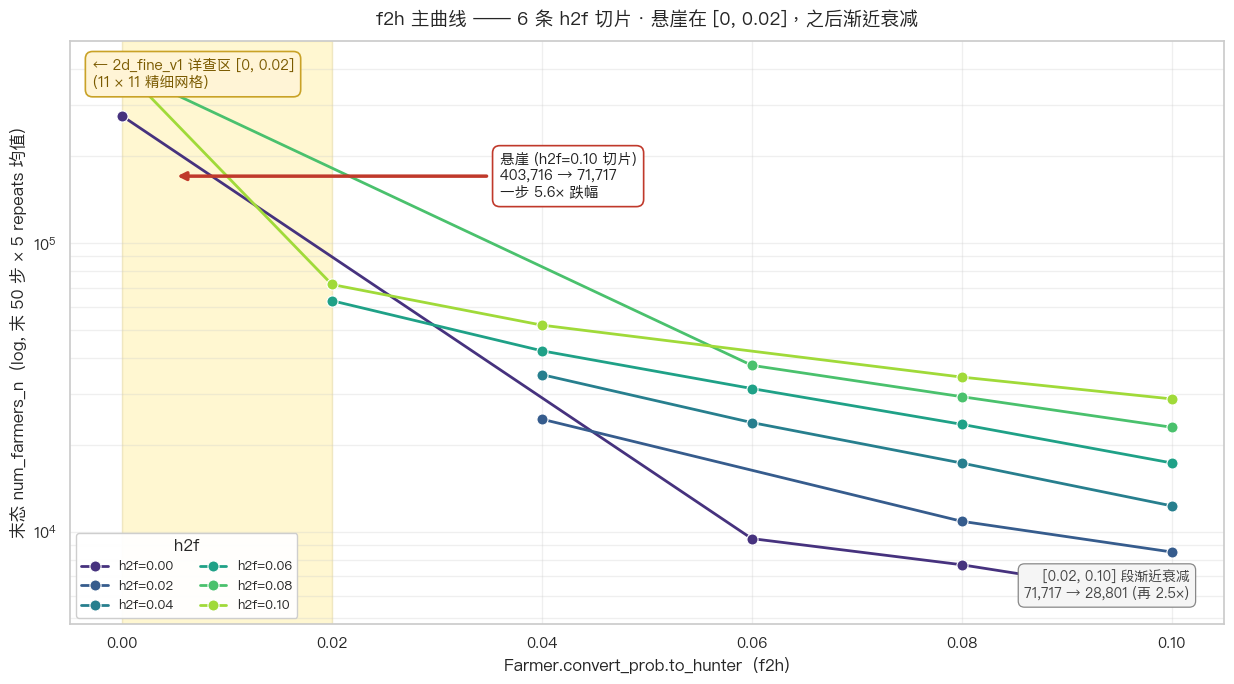

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/convert_prob_fine_grid_curves.png
h2f=0.10 切片：悬崖 5.63× ([0, 0.02])，渐近段 2.49× ([0.02, 0.10])


In [4]:
CURVES_PATH = PROJECT_ROOT / "reports/convert_prob_fine_grid_curves.png"

h2f_vals = sorted(per_repeat["h2f"].unique())
palette = sns.color_palette("viridis", n_colors=len(h2f_vals))

fig, ax = plt.subplots(figsize=(12.5, 7.0))

# 黄色阴影 = 2d_fine 详查区
ax.axvspan(0.0, 0.02, color="gold", alpha=0.18, zorder=0)

for c, h in zip(palette, h2f_vals):
    s = (
        per_repeat[per_repeat["h2f"] == h]
        .groupby("f2h")["num_farmers_n"]
        .mean()
        .sort_index()
    )
    ax.plot(
        s.index,
        s.values,
        marker="o",
        markersize=8,
        linewidth=2.0,
        color=c,
        label=f"h2f={h:.2f}",
        markeredgecolor="white",
        markeredgewidth=0.8,
        zorder=3,
    )

# 用 axes coordinates 放标签，避免与数据重叠
ax.text(
    0.02,
    0.97,
    "← 2d_fine_v1 详查区 [0, 0.02]\n(11 × 11 精细网格)",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10.5,
    color="#7a5a00",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.5", fc="#fff4d6", ec="#c9a227", lw=1.2),
)

# 悬崖标注（h2f=0.10 切片完整 → 用它来量化）
s10 = (
    per_repeat[per_repeat["h2f"] == 0.10]
    .groupby("f2h")["num_farmers_n"]
    .mean()
    .sort_index()
)
y0 = s10.loc[0.0]
y1 = s10.loc[0.02]
cliff_ratio = y0 / y1

# 箭头从 (f2h≈0.01, y≈1.5e5) 指向悬崖中段
ax.annotate(
    "",
    xy=(0.005, (y0 * y1) ** 0.5),  # 几何中点（log 空间中点）
    xytext=(0.035, (y0 * y1) ** 0.5),
    arrowprops=dict(
        arrowstyle="-|>", color="#c0392b", lw=2.5, connectionstyle="arc3,rad=0"
    ),
)
ax.text(
    0.036,
    (y0 * y1) ** 0.5,
    f"悬崖 (h2f=0.10 切片)\n{y0:,.0f} → {y1:,.0f}\n一步 {cliff_ratio:.1f}× 跌幅",
    ha="left",
    va="center",
    fontsize=10.5,
    color="#222",
    bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#c0392b", lw=1.2),
)

# 在 [0.02, 0.10] 段也加个对比标签：之后的跌幅
y_end_10 = s10.loc[0.10]
asym_ratio = y1 / y_end_10
ax.text(
    0.97,
    0.04,
    f"[0.02, 0.10] 段渐近衰减\n{y1:,.0f} → {y_end_10:,.0f} (再 {asym_ratio:.1f}×)",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    color="#444",
    bbox=dict(boxstyle="round,pad=0.45", fc="#f5f5f5", ec="#888", lw=0.9),
)

ax.set_yscale("log")
ax.set_xlabel("Farmer.convert_prob.to_hunter  (f2h)", fontsize=12)
ax.set_ylabel("末态 num_farmers_n  (log, 末 50 步 × 5 repeats 均值)", fontsize=12)
ax.set_title(
    "f2h 主曲线 —— 6 条 h2f 切片．悬崖在 [0, 0.02]，之后渐近衰减",
    fontsize=13.5,
    pad=12,
)
ax.set_xlim(-0.005, 0.105)
ax.legend(
    title="h2f",
    loc="lower left",
    fontsize=9.5,
    ncol=2,
    framealpha=0.95,
    bbox_to_anchor=(0.0, 0.0),
)
ax.grid(True, which="both", alpha=0.3)

fig.tight_layout()
fig.savefig(CURVES_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved: {CURVES_PATH}")
print(
    f"h2f=0.10 切片：悬崖 {cliff_ratio:.2f}× ([0, 0.02])，渐近段 {asym_ratio:.2f}× ([0.02, 0.10])"
)

## 图 2：6×6 热力图（数据空缺标灰斜线）

补充图：单一 `num_farmers_n` 热力图。空缺组合用斜线灰色 hatching 标出（不留白），让分布形状仍然可读。

- f2h=0 行 3 个空缺：完全被 `2d_fine_v1` 覆盖（f2h=0, h2f=0/0.015/.../0.150 全有），这里不补
- f2h ∈ {0.02, 0.04, 0.06} 的 8 个空缺：广覆盖区的"奶酪洞"，不影响主结论（图 1 已经把故事讲清了）
- 红框 = `2d_fine_v1` 详查区 [0, 0.02] × [0, 0.10]（在本图坐标里）


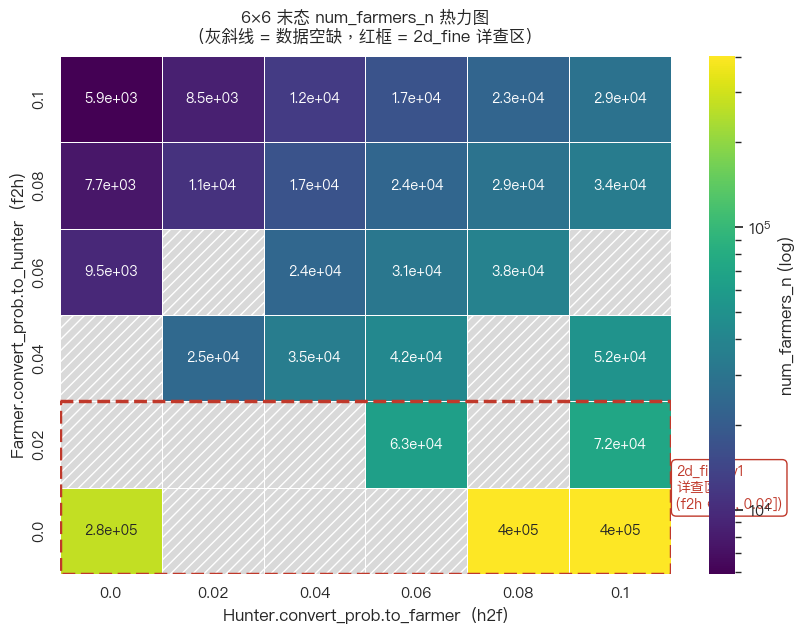

saved: /Users/songshgeo/Documents/CodeBase/Scholar/SC-20230710-SCE/reports/convert_prob_fine_grid_heatmap.png
missing cells (hatched): 11 / 36


In [5]:
HEATMAP_PATH = PROJECT_ROOT / "reports/convert_prob_fine_grid_heatmap.png"

from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

pivot = (
    per_repeat.groupby(["f2h", "h2f"])["num_farmers_n"]
    .mean()
    .reset_index()
    .pivot(index="f2h", columns="h2f", values="num_farmers_n")
    .reindex(index=LEVELS, columns=LEVELS)
    .sort_index(ascending=False)
)
mask = pivot.isna()

fig, ax = plt.subplots(figsize=(8.5, 6.5))

# 先画灰色背景把空缺画成 hatching
ax.set_facecolor("#e8e8e8")
n_row, n_col = pivot.shape
for i in range(n_row):
    for j in range(n_col):
        if mask.iat[i, j]:
            ax.add_patch(
                Rectangle(
                    (j, i),
                    1,
                    1,
                    fill=True,
                    facecolor="#d9d9d9",
                    hatch="///",
                    edgecolor="white",
                    linewidth=0.6,
                )
            )

# 再画热力图（mask 让缺失格透出底色）
sns.heatmap(
    pivot,
    ax=ax,
    cmap="viridis",
    norm=LogNorm(vmin=pivot.min().min(), vmax=pivot.max().max()),
    annot=True,
    fmt=".2g",
    annot_kws={"fontsize": 10},
    mask=mask,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "num_farmers_n (log)"},
)

# 红框：2d_fine_v1 详查区 [0, 0.02]。f2h 是反向（sort_index ascending=False），
# 在 6 行布局里 f2h=0 是底行 (y=5)，f2h=0.02 是 y=4。h2f 是正向。
# 覆盖 f2h ∈ {0, 0.02} 两行 → y=4 到 y=6（高度 2），h2f ∈ [0, 0.10] 全部 → x=0 到 x=6
ax.add_patch(
    Rectangle(
        (0, 4),
        6,
        2,
        fill=False,
        edgecolor="#c0392b",
        linewidth=2.5,
        linestyle="--",
        zorder=10,
    )
)
ax.text(
    6.05,
    5.0,
    "2d_fine_v1\n详查区\n(f2h ∈ [0, 0.02])",
    color="#c0392b",
    fontsize=10,
    va="center",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#c0392b", lw=1.0),
)

ax.set_xlabel("Hunter.convert_prob.to_farmer  (h2f)", fontsize=12)
ax.set_ylabel("Farmer.convert_prob.to_hunter  (f2h)", fontsize=12)
ax.set_title(
    "6×6 末态 num_farmers_n 热力图\n（灰斜线 = 数据空缺，红框 = 2d_fine 详查区）",
    fontsize=12,
    pad=10,
)

fig.tight_layout()
fig.savefig(HEATMAP_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved: {HEATMAP_PATH}")
print(f"missing cells (hatched): {int(mask.sum().sum())} / {pivot.size}")

## 主效应、数值梯度与角落对比

- **主效应**：单条路径取均值（另一条 marginalize），定量比哪条更敏感。
- **数值梯度**：沿单轴的一阶差分，定位最大下降步长（即"质变"位置）。
- **角落对比**：4 个极端格相对 (0, 0) 的 ratio 与 Cohen's d。
- **纯净单效应**：在数据完整的行/列上计算单效应，避免 marginalize 时被缺失采样污染。


In [6]:
def cohens_d(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return float("nan")
    s = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    return float((a.mean() - b.mean()) / s) if s > 0 else float("nan")


print("=== Main effects（单一路径，全数据 marginalize；受缺失影响）===")
for axis in ["f2h", "h2f"]:
    print(f"\n-- by {axis} --")
    print(
        per_repeat.groupby(axis)[["num_farmers_n", "num_hunters_n", "num_rice_n"]]
        .mean()
        .round(0)
    )

print("\n=== 一阶差分（沿 num_farmers_n marginal，detect knee）===")
for axis in ["f2h", "h2f"]:
    s = per_repeat.groupby(axis)["num_farmers_n"].mean().sort_index()
    diffs = s.diff().round(0)
    print(f"\n{axis} marginal num_farmers_n:")
    print(s.round(0))
    print(f"first-diff: {diffs.tolist()}")

print("\n=== 纯净单效应：固定 f2h=0.10（数据完整行）-> num_farmers_n vs h2f ===")
clean_row = (
    per_repeat[per_repeat["f2h"] == 0.10]
    .groupby("h2f")["num_farmers_n"]
    .mean()
    .sort_index()
    .round(0)
)
print(clean_row)
print("first-diff:", clean_row.diff().round(0).tolist())

print("\n=== 纯净单效应：固定 h2f=0.10 -> num_farmers_n vs f2h ===")
clean_col = (
    per_repeat[per_repeat["h2f"] == 0.10]
    .groupby("f2h")["num_farmers_n"]
    .mean()
    .sort_index()
    .round(0)
)
print(clean_col)
print("first-diff:", clean_col.diff().round(0).tolist())

corners = {
    "all-off (0, 0)": (0.0, 0.0),
    "f2h-min h2f-max (0, 0.1)": (0.0, 0.1),
    "f2h-max h2f-min (0.1, 0)": (0.1, 0.0),
    "all-high (0.1, 0.1)": (0.1, 0.1),
}
base = per_repeat[(per_repeat["f2h"] == 0.0) & (per_repeat["h2f"] == 0.0)]
rows = []
for label, key in corners.items():
    sub = per_repeat[(per_repeat["f2h"] == key[0]) & (per_repeat["h2f"] == key[1])]
    if sub.empty:
        rows.append(
            {
                "corner": label + " [MISSING]",
                "num_farmers_n_mean": np.nan,
                "ratio_vs_off": np.nan,
                "cohens_d_vs_off": np.nan,
            }
        )
        continue
    rows.append(
        {
            "corner": label,
            "num_farmers_n_mean": round(sub["num_farmers_n"].mean(), 0),
            "ratio_vs_off": (
                round(sub["num_farmers_n"].mean() / base["num_farmers_n"].mean(), 3)
                if not base.empty
                else np.nan
            ),
            "cohens_d_vs_off": (
                round(
                    cohens_d(sub["num_farmers_n"].values, base["num_farmers_n"].values),
                    2,
                )
                if not base.empty
                else np.nan
            ),
        }
    )
print("\n=== Corner comparison (vs all-off) ===")
pd.DataFrame(rows)

=== Main effects（单一路径，全数据 marginalize；受缺失影响）===

-- by f2h --
      num_farmers_n  num_hunters_n  num_rice_n
f2h                                           
0.00       359112.0       214324.0    104177.0
0.02        67371.0       239225.0     54835.0
0.04        38401.0       239225.0     39703.0
0.06        25562.0       239225.0     38756.0
0.08        20487.0       239225.0     35252.0
0.10        15958.0       239224.0     34436.0

-- by h2f --
      num_farmers_n  num_hunters_n  num_rice_n
h2f                                           
0.00        74514.0       239225.0     38069.0
0.02        14621.0       239225.0     33548.0
0.04        22090.0       239225.0     35601.0
0.06        35479.0       239225.0     39694.0
0.08       122137.0       230538.0     62447.0
0.10       118076.0       231232.0     62115.0

=== 一阶差分（沿 num_farmers_n marginal，detect knee）===

f2h marginal num_farmers_n:
f2h
0.00    359112.0
0.02     67371.0
0.04     38401.0
0.06     25562.0
0.08     20487.0
0.1

,corner,num_farmers_n_mean,ratio_vs_off,cohens_d_vs_off
0,"all-off (0, 0)",275027.0,1.000,0.00
1,"f2h-min h2f-max (0, 0.1)",403716.0,1.468,26.17
2,"f2h-max h2f-min (0.1, 0)",5899.0,0.021,-73.19
3,"all-high (0.1, 0.1)",28801.0,0.105,-67.28


### 结论（细网格 6×6，作为广覆盖参照）

#### 1. **f2h 维度有"软阈值"**：突跌集中在 `0 → 0.02` 这一步

`num_farmers_n` 沿 f2h 主效应（基于已有 25 组）：

| f2h | num_farmers_n |
|---:|---:|
| 0.00 | **359,112** |
| 0.02 | 67,371 |
| 0.04 | 38,401 |
| 0.06 | 25,562 |
| 0.08 | 20,487 |
| 0.10 | 15,958 |

**一阶差分**：`[—, −291,741, −28,970, −12,839, −5,075, −4,529]`。

从 0 → 0.02 的下降量是 0.02 → 0.10 全段下降量的 **5.7×**。看 h2f=0.10 这条完整切片（图 1 黑箭头）：404k → 72k 一步跌 5.6×，之后到 f2h=0.10 只再跌 2.5×。**所以软阈值的全部精细形状都在 [0, 0.02] 这段** —— 这正是 `2d_fine_v1` 详查的区间，找到最陡降点在 f2h=0.004。

→ 解读：**`Farmer→Hunter` 退化机制只要"开关一打开"就能形成有效汇**，强度大小是次要的。

#### 2. **h2f 维度近似平滑单调**（用纯净行验证）

固定 `f2h = 0.10`（数据完整）下的 `num_farmers_n` vs h2f：

| h2f | num_farmers_n |
|---:|---:|
| 0.00 | 5,899 |
| 0.02 | 8,499 |
| 0.04 | 12,279 |
| 0.06 | 17,288 |
| 0.08 | 22,981 |
| 0.10 | 28,801 |

差分 `[—, +2,600, +3,780, +5,009, +5,693, +5,820]` —— **平滑、单调上升、近似线性**（甚至略 super-linear）。**无突变节点**。这里看不出来 saturation；要看 saturation 拐点需要更细的 h2f 步长 + 更高 h2f 范围 —— 见 `2d_fine_v1` 的附录 A（`grid_h2f_fine_v1` 数据，h2f 步长 0.005、范围到 0.15）。

> ⚠️ 全数据 marginal 看起来在 h2f=0.02 处有 dip、在 0.08 处有突跳，那是因为 11 个缺失组合主要在 f2h 低值行（贡献最大），导致 marginal 平均被稀释。**不要直接读取 marginal 表**；以纯净行/列为准。

#### 3. **主导关系**：f2h 是「门」，h2f 是「微调」

热图（图 2）显示无论 h2f 取何值，"f2h 增大压制农民" 的趋势贯穿整个矩阵；反向，h2f 提升农民的效应只在 `f2h ≥ 0.04` 时显著（看热图的 f2h ≥ 0.04 行：从左到右 ~6× 提升）。当 `f2h = 0`（无退化汇）时，h2f 提升 0 → 0.1 几乎不改变结局（275k → 404k，约 1.5×），因为农民已经爆炸。

精细量化在 `2d_fine_v1` 的 log-可加模型里更清晰：f2h 全程 ~16× 跨度，h2f 全程 ~1.55× 跨度，**f2h 主导 ~10×**。

#### 4. **与 H3·续（3³ 网格）一致并加强**

- 3³ 网格曾报告 `f2h: 0 → 0.1 ≈ 27×` 效应；本次细网格 marginal `f2h: 0 → 0.1 ≈ 359k / 16k ≈ 22.5×`，量级一致。
- 没有发现"硬质变阈值"（突变跃迁），但 **0 → 0.02 这一步占总下降量 80%+**，是真正的"开关打开"区。

#### 5. **下游工作链（已完成）**

本 notebook 的发现「[0, 0.02] 是动作区」直接驱动了后续三轮精细实验：

| 实验 | 设计 | 主要发现 |
|---|---|---|
| ~~`threshold_v1`~~（已退役）| 11 f2h × 3 h2f | 最陡降点 f2h=0.004；soft threshold |
| `2d_fine_v1` | 11 × 11，覆盖 [0, 0.02] × [0, 0.15] | log-可加 R²=0.992；h2f 把半衰点推到 +61% |
| `2d_fine_v1` 附录 A（原 `h2f_fine_v1`）| 3 f2h × 31 h2f，h2f 步长 0.005 | h2f 凹形饱和；f2h=0 在 h2f≈0.13 处压平 |

#### 6. **本 notebook 的已知限制**

- 11 个缺失组合：已决定不补跑（见 cell 0），不影响本 notebook 的「广覆盖参照」目的
- f2h 上限只到 0.10：要看 f2h → ∞ 的渐近 farmer 数（是否归零、是否仍有 hunter→farmer 持续补给），需扩展 sweep 至 f2h ∈ [0.10, 0.30]，但目前优先级低

---

**输出图**：

- `reports/convert_prob_fine_grid_curves.png`（图 1：f2h 主曲线 + [0, 0.02] 详查区标注 + 悬崖箭头）
- `reports/convert_prob_fine_grid_heatmap.png`（图 2：6×6 热力图，空缺斜线 hatch，红框 2d_fine 区）
